In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [38]:
df = pd.read_csv("creditcard.csv")

In [39]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [40]:
df.shape

(284807, 31)

In [41]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [43]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [44]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [45]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [46]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [47]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [48]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (283726, 31)


In [49]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print(
    "Infinite values:",
    np.isinf(df[numeric_cols]).sum().sum()
)

Infinite values: 0


In [50]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [51]:
print(
    df["Class"].value_counts(normalize=True) * 100
)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [52]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print(X_train.columns.tolist())

X_train: (226980, 30)
X_test: (56746, 30)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [56]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("\nFirst 5 rows:")
display(X_train_scaled.head())

Training shape: (226980, 30)
Testing shape: (56746, 30)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434
134253,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197
186465,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809
149493,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247
18461,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985


In [57]:
print(
    "NaN:",
    X_train_scaled.isnull().sum().sum()
)

print(
    "Infinite:",
    np.isinf(X_train_scaled).sum().sum()
)

NaN: 0
Infinite: 0


In [105]:
import joblib

joblib.dump(
    scaler,
    "/content/scaler.pkl"
)

['/content/scaler.pkl']

In [59]:
fraud_count = (y_train == 1).sum()
legitimate_count = (y_train == 0).sum()

scale_pos_weight = legitimate_count / fraud_count

print("Legitimate transactions:", legitimate_count)
print("Fraud transactions:", fraud_count)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate transactions: 226602
Fraud transactions: 378
Scale Pos Weight: 599.4761904761905


In [60]:
from xgboost import XGBClassifier

In [61]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [62]:
model.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [63]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [64]:
print(y_prob[:10])

[2.6145572e-05 6.2863117e-05 1.3684452e-04 2.2255837e-05 2.8060397e-04
 6.1916377e-05 1.7545024e-05 3.4648233e-06 6.1583507e-04 8.9090745e-06]


In [65]:
y_pred = (y_prob >= 0.5).astype(int)

In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56651
           1     0.9268    0.8000    0.8588        95

    accuracy                         0.9996     56746
   macro avg     0.9632    0.8999    0.9293     56746
weighted avg     0.9995    0.9996    0.9995     56746



In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56645     6]
 [   19    76]]


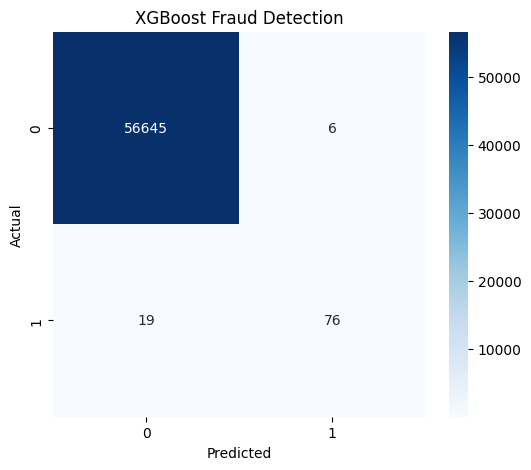

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Fraud Detection")

plt.show()

In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.10,0.700000,0.810526,0.751220
1,0.15,0.754902,0.810526,0.781726
2,0.20,0.785714,0.810526,0.797927
3,0.25,0.819149,0.810526,0.814815
4,0.30,0.855556,0.810526,0.832432
5,0.35,0.855556,0.810526,0.832432
6,0.40,0.865169,0.810526,0.836957
7,0.45,0.894118,0.800000,0.844444
8,0.50,0.926829,0.800000,0.858757
9,0.55,0.926829,0.800000,0.858757


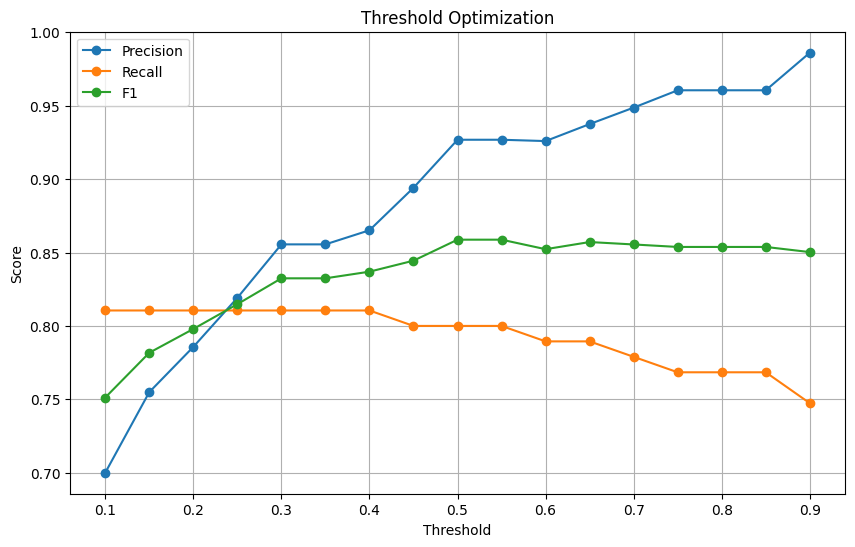

In [70]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [71]:
high_recall = threshold_df[
    threshold_df["Recall"] >= 0.90
]

display(
    high_recall.sort_values(
        "F1",
        ascending=False
    )
)

,Threshold,Precision,Recall,F1


In [72]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.500000
Precision    0.926829
Recall       0.800000
F1           0.858757
Name: 8, dtype: float64


In [73]:
best_threshold = float(best_row["Threshold"])

print("Selected threshold:", best_threshold)

Selected threshold: 0.5000000000000001


In [74]:
import json

config = {
    "threshold": best_threshold
}

with open("/content/config.json", "w") as f:
    json.dump(config, f)

In [106]:
import joblib

joblib.dump(
    model,
    "/content/xgboost_fraud_model.pkl"
)

['/content/xgboost_fraud_model.pkl']

In [76]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [77]:
X_train_dl = X_train_scaled.values.astype("float32")
X_test_dl = X_test_scaled.values.astype("float32")

y_train_dl = y_train.values.astype("float32")
y_test_dl = y_test.values.astype("float32")

In [78]:
print("X_train:", X_train_dl.shape)
print("X_test:", X_test_dl.shape)
print("y_train:", y_train_dl.shape)
print("y_test:", y_test_dl.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


In [79]:
import numpy as np

legitimate = np.sum(y_train_dl == 0)
fraud = np.sum(y_train_dl == 1)

weight_for_0 = 1.0
weight_for_1 = legitimate / fraud

class_weight = {
    0: weight_for_0,
    1: weight_for_1
}

print("Legitimate:", legitimate)
print("Fraud:", fraud)
print("Fraud class weight:", weight_for_1)

Legitimate: 226602
Fraud: 378
Fraud class weight: 599.4761904761905


In [80]:
model_dl = keras.Sequential([

    layers.Input(shape=(X_train_dl.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(1, activation="sigmoid")
])

In [81]:
model_dl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [82]:
model_dl.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

In [83]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

In [84]:
history = model_dl.fit(
    X_train_dl,
    y_train_dl,

    validation_split=0.20,

    epochs=20,
    batch_size=1024,

    class_weight=class_weight,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.7979 - pr_auc: 0.2682 - precision: 0.0065 - recall: 0.8900 - roc_auc: 0.9174 - val_loss: 0.2009 - val_pr_auc: 0.8041 - val_precision: 0.0987 - val_recall: 0.8974 - val_roc_auc: 0.9641
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4124 - pr_auc: 0.3535 - precision: 0.0234 - recall: 0.9067 - roc_auc: 0.9694 - val_loss: 0.1287 - val_pr_auc: 0.5112 - val_precision: 0.0522 - val_recall: 0.9103 - val_roc_auc: 0.9765
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.3608 - pr_auc: 0.3499 - precision: 0.0288 - recall: 0.9200 - roc_auc: 0.9762 - val_loss: 0.0946 - val_pr_auc: 0.6869 - val_precision: 0.0703 - val_recall: 0.9103 - val_roc_auc: 0.9808
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.3035 - pr_auc: 0.4559 - precision: 0.0334 - recall: 0.9267 - roc_auc: 0.9834 - val_loss: 0.0766 - val_pr_auc: 0.7160 - val_precision: 0.0856 - val_recall: 0.9231 - val_roc_auc: 0.9821


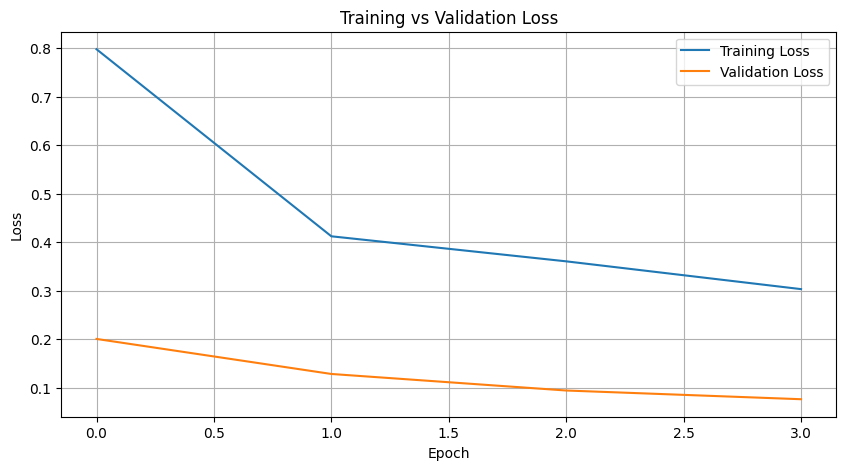

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

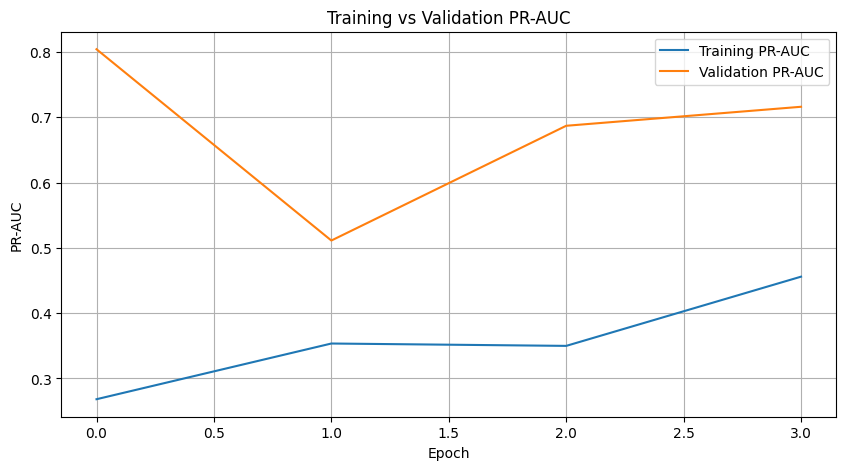

In [86]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["pr_auc"],
    label="Training PR-AUC"
)

plt.plot(
    history.history["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training vs Validation PR-AUC")
plt.legend()
plt.grid(True)

plt.show()

In [87]:
results = model_dl.evaluate(
    X_test_dl,
    y_test_dl,
    verbose=1
)

print(results)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2013 - pr_auc: 0.6813 - precision: 0.0966 - recall: 0.8421 - roc_auc: 0.9470
[0.2013455331325531, 0.09661835432052612, 0.8421052694320679, 0.9469544291496277, 0.6813230514526367]


In [88]:
model_dl.evaluate(
    X_test_dl,
    y_test_dl,
    return_dict=True
)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2013 - pr_auc: 0.6813 - precision: 0.0966 - recall: 0.8421 - roc_auc: 0.9470


{'loss': 0.2013455331325531,
 'pr_auc': 0.6813230514526367,
 'precision': 0.09661835432052612,
 'recall': 0.8421052694320679,
 'roc_auc': 0.9469544291496277}

In [89]:
dl_prob = model_dl.predict(
    X_test_dl,
    batch_size=1024
).ravel()

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [90]:
print(dl_prob[:20])

[0.09771343 0.13499035 0.34198177 0.24237387 0.2937424  0.14501157
 0.163958   0.14908583 0.49465093 0.12230904 0.12751824 0.31573567
 0.20855911 0.14242387 0.3181887  0.11534978 0.30302188 0.05660812
 0.22996747 0.2252245 ]


In [91]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

dl_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        dl_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test_dl,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test_dl,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test_dl,
        predictions,
        zero_division=0
    )

    dl_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

dl_threshold_df = pd.DataFrame(
    dl_results
)

display(
    dl_threshold_df.sort_values(
        "F1",
        ascending=False
    )
)

,Threshold,Precision,Recall,F1
16,0.90,0.760417,0.768421,0.764398
15,0.85,0.718447,0.778947,0.747475
14,0.80,0.601626,0.778947,0.678899
13,0.75,0.435294,0.778947,0.558491
12,0.70,0.324675,0.789474,0.460123
11,0.65,0.235110,0.789474,0.362319
10,0.60,0.163441,0.800000,0.271429
9,0.55,0.123397,0.810526,0.214186
8,0.50,0.096618,0.842105,0.173348
7,0.45,0.069991,0.842105,0.129241


In [92]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

dl_roc_auc = roc_auc_score(
    y_test_dl,
    dl_prob
)

dl_pr_auc = average_precision_score(
    y_test_dl,
    dl_prob
)

print("Deep Learning ROC-AUC:", dl_roc_auc)
print("Deep Learning PR-AUC:", dl_pr_auc)

Deep Learning ROC-AUC: 0.9469458893743689
Deep Learning PR-AUC: 0.6595824390794092


In [93]:
best_dl_row = dl_threshold_df.loc[
    dl_threshold_df["F1"].idxmax()
]

print(best_dl_row)

Threshold    0.900000
Precision    0.760417
Recall       0.768421
F1           0.764398
Name: 16, dtype: float64


In [94]:
best_dl_threshold = float(
    best_dl_row["Threshold"]
)

dl_pred = (
    dl_prob >= best_dl_threshold
).astype(int)

In [95]:
from sklearn.metrics import confusion_matrix

cm_dl = confusion_matrix(
    y_test_dl,
    dl_pred
)

print(cm_dl)

[[56628    23]
 [   22    73]]


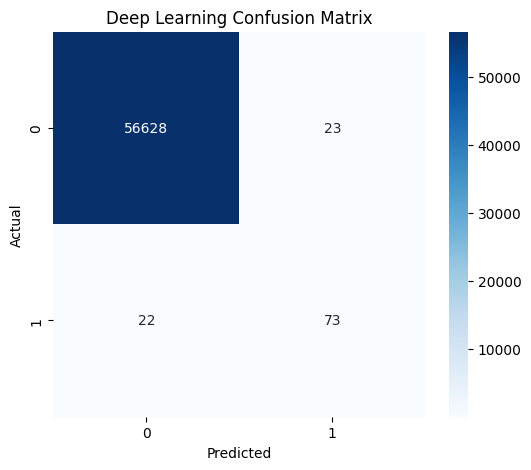

In [96]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dl,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep Learning Confusion Matrix")

plt.show()

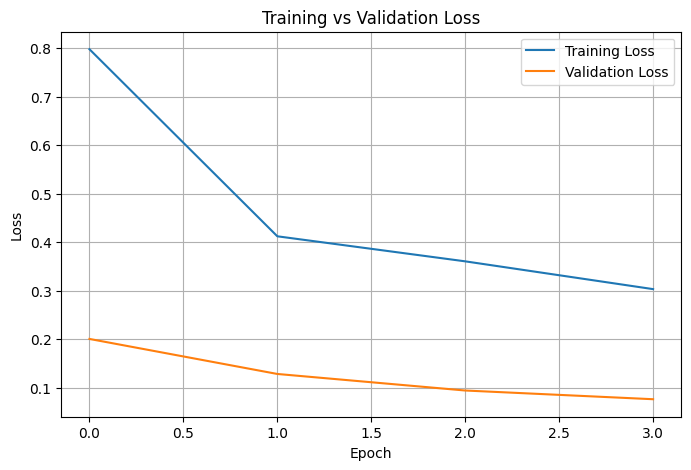

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "TensorFlow MLP"
    ],

    "Precision": [
        0.9268,
        best_dl_row["Precision"]
    ],

    "Recall": [
        0.8000,
        best_dl_row["Recall"]
    ],

    "F1": [
        0.8588,
        best_dl_row["F1"]
    ],

    "ROC-AUC": [
        0.9745,
        dl_roc_auc
    ],

    "PR-AUC": [
        0.8224,
        dl_pr_auc
    ]
})

display(comparison)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.926800,0.800000,0.858800,0.974500,0.822400
1,TensorFlow MLP,0.760417,0.768421,0.764398,0.946946,0.659582


In [100]:
model_dl.save(
    "/content/fraud_detection_dl.keras"
)

In [102]:
import json

feature_info = {
    "features": X_train.columns.tolist()
}

with open("/content/features.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print(feature_info)

{'features': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']}


In [103]:
import json

with open("/content/features.json", "r") as f:
    print(json.load(f))

{'features': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']}


In [108]:
import joblib

MODEL_PATH = "/content/xgboost_fraud_model.pkl"

frozen_model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")
print(type(frozen_model))

Model loaded successfully!
<class 'xgboost.sklearn.XGBClassifier'>


In [109]:
SCALER_PATH = "/content/scaler.pkl"

frozen_scaler = joblib.load(SCALER_PATH)

print("Scaler loaded successfully!")
print(type(frozen_scaler))

Scaler loaded successfully!
<class 'sklearn.preprocessing._data.StandardScaler'>


In [110]:
print(type(X_test_scaled))
print(X_test_scaled.shape)

<class 'pandas.core.frame.DataFrame'>
(56746, 30)


In [111]:
frozen_prob = frozen_model.predict_proba(
    X_test_scaled
)[:, 1]

frozen_pred = (
    frozen_prob >= 0.50
).astype(int)

print("Probabilities:", frozen_prob[:10])
print("Predictions:", frozen_pred[:10])

Probabilities: [2.6145572e-05 6.2863117e-05 1.3684452e-04 2.2255837e-05 2.8060397e-04
 6.1916377e-05 1.7545024e-05 3.4648233e-06 6.1583507e-04 8.9090745e-06]
Predictions: [0 0 0 0 0 0 0 0 0 0]


In [112]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Precision:",
      precision_score(y_test, frozen_pred))

print("Recall:",
      recall_score(y_test, frozen_pred))

print("F1 Score:",
      f1_score(y_test, frozen_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, frozen_prob))

print("PR-AUC:",
      average_precision_score(y_test, frozen_prob))

Precision: 0.926829268292683
Recall: 0.8
F1 Score: 0.8587570621468926
ROC-AUC: 0.9745301100273234
PR-AUC: 0.8223862396219062
